<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Module_05_Summer26_Starter_Nortebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO510 - Module 05 In-Class Activity
## Working with categorical variables
In this notebook you are required to develop a linear-regression model to predict the final Portuguese-language grade, **`G3`**, using demographic, family, behavioural, and school-related variables.

### Learning objectives

By completing the notebook sequentially, you will:

1. load and inspect a semicolon-delimited dataset;

2. clean the data without overwriting the original DataFrame;

3. separate the target from the predictors and split `before` preprocessing;

4. distinguish nominal, ordinal, binary, and numerical variables;

5. fit preprocessing transformations `only on the training data`;

6. combine the transformed variables into model-ready datasets;

7. conduct correlation and multicollinearity screening;

8. fit and evaluate a multiple linear-regression model;

9. distinguish predictive metrics from inferential statistics;

10. examine regression assumptions and predictor significance;

11. reproduce the workflow using a scikit-learn pipeline.

**Important:**

In this notebook, as directed in your activity descrition, you will intentionally exclude `G1` and `G2`. These earlier grades are highly predictive of `G3`, but retaining them would dominate the model and weaken the activity's focus on categorical-variable preprocessing.

## 1- Import the required libraries

Begin by importing libraries for:

- data manipulation (`pandas`, `numpy`);
- visualization (`matplotlib`);
- preprocessing and model building (`scikit-learn`);
- regression inference and diagnostics (`statsmodels`, `scipy`).

In [ ]:
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = file_path = '/content/drive/MyDrive/Predictive Analytics Course/student-por.csv'

df_a = pd.read_csv(data_path, sep = ";")
df_a.columns = df_a.columns.str.strip().str.lower()


print("Initial shape:", df_a.shape)
display(df_a.head())
display(df_a.info())

Initial shape: (649, 33)


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   pstatus     649 non-null    object
 6   medu        649 non-null    int64 
 7   fedu        649 non-null    int64 
 8   mjob        649 non-null    object
 9   fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

None

## 2 - Load the dataset

The CSV file uses a **semicolon (`;`) delimiter**, not a comma. You load it into `df_a`, which represents the original imported dataset.

After loading, report its dimensions and display the first five records. These checks confirm that the delimiter was interpreted correctly.

In [ ]:
DATA_PATH = '/content/drive/MyDrive/Predictive Analytics Course/student-por.csv'
df_a = pd.read_csv(DATA_PATH, sep = ";")

print(f"Initial shape: {df_a.shape[0]} x {df_a.shape[1]}")
df_a.head()

Initial shape: 649 x 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


## 3 - Inspect the structure and data types

Before cleaning or modelling, examine:

- column names;
- non-null counts;
- stored data types;
- descriptive statistics for numerical variables.

In [ ]:
print("Column names:")
print(df_a.columns.tolist())

print("\nDataFrame information:")
df_a.info()

print("\nNumerical summary:")
display(df_a.describe().T)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guar

,count,mean,std,min,25%,50%,75%,max
age,649.0000,16.7442,1.2181,15.0000,16.0000,17.0000,18.0000,22.0000
Medu,649.0000,2.5146,1.1346,0.0000,2.0000,2.0000,4.0000,4.0000
Fedu,649.0000,2.3066,1.0999,0.0000,1.0000,2.0000,3.0000,4.0000
traveltime,649.0000,1.5686,0.7487,1.0000,1.0000,1.0000,2.0000,4.0000
studytime,649.0000,1.9307,0.8295,1.0000,1.0000,2.0000,2.0000,4.0000
failures,649.0000,0.2219,0.5932,0.0000,0.0000,0.0000,0.0000,3.0000
famrel,649.0000,3.9307,0.9557,1.0000,4.0000,4.0000,5.0000,5.0000
freetime,649.0000,3.1803,1.0511,1.0000,3.0000,3.0000,4.0000,5.0000
goout,649.0000,3.1849,1.1758,1.0000,2.0000,3.0000,4.0000,5.0000
Dalc,649.0000,1.5023,0.9248,1.0000,1.0000,1.0000,2.0000,5.0000


## 4 - Check duplicates, missing values, and target range

A basic cleaning audit should answer three questions:

1. Are any complete rows duplicated?
2. Are any values missing?
3. Does the target `G3` stay within its documented range of 0 to 20?

In [ ]:
# create a dictionary then convert it to a series.
quality_report = pd.Series({
    "duplicate_rows": df_a.duplicated().sum(),
    "total_missing_values": df_a.isna().sum().sum(),
    "columns_with_missing_values": (df_a.isna().sum() > 0).sum(),
    "minimum_G3": df_a["G3"].min(),
    "maximum_G3": df_a["G3"].max()
})

quality_report.to_frame("result")  # converts the Series into a DataFrame just a better visual, nothing more!

# Dictionary : Python data structure (key-value pairs)
# Series : One-dimensional Pandas object with an index
# DataFrame : Two-dimensional Pandas table

,result
duplicate_rows,0
total_missing_values,0
columns_with_missing_values,0
minimum_G3,0
maximum_G3,19


## 5 Create a cleaned working copy

Assigning `df_b = df_a` would create a second reference to the same object. Instead, `.copy()` creates an independent working DataFrame.

If duplicate rows or missing values existed, this would be the appropriate stage to address them.

In [ ]:
df_b = df_a.copy()


df_b = df_b.drop_duplicates().reset_index(drop = True)

print(f"Original shape: {df_a.shape}")
print(f"Working-copy shape after cleaning: {df_b.shape}")

Original shape: (649, 33)
Working-copy shape after cleaning: (649, 33)


## 6 - Define the target and predictor matrix (also called design matrix)

`G3` is the prediction target. Remove `G1` and `G2` from the predictor matrix because they are earlier period grades and are strongly correlated with the final grade.

The resulting predictor matrix contains the non-grade variables that this activity is designed to preprocess and evaluate.

In [ ]:
y = df_b["G3"].copy()  # why this is a better practice than y = df_b["G3"]?
X = df_b.drop(columns = ["G1", "G2", "G3"]).copy() # same here.

print(f"Predictor matrix shape: {X.shape}")
print(f"Target vector length: {len(y)}")
print("\nColumns excluded from X: G1, G2, G3")

Predictor matrix shape: (649, 30)
Target vector length: 649

Columns excluded from X: G1, G2, G3


# What is Data Leakage?

Data leakage occurs whenever information from the `testing data influences the training process`. `any` information from the testing data.

The testing set is supposed to represent completely unseen future data. If we let the training process look at it (such as encoding stage), even indirectly, we are no longer evaluating the model fairly.

## But, during encoding the encoder isn't using G3, so why is it leakage?"

Encoding is called unsupervised preprocessing. It doesn't use the target.

However, it still `learns something from the data`:

- categories
- frequencies (depending on encoder)
- scaling parameters (for scalers)
- means
- variances
- etc.

Those characteristics belong only to the training data.

## 7 - So, split before fitting any encoder

The test set must simulate unseen data. Therefore, every transformation that `learns from data` must be fitted **`only on the training set`**.

Use an 80/20 split and fix `random_state = 42` so everyone obtains reproducible results. No encoding should occur before this step.

# Why do we split before encoding?

Encoders such as `OneHotEncoder` and `OrdinalEncoder` learn information from the data, including the categories that exist in each feature. If they are fitted using the entire dataset before the train-test split, information from the testing set leaks into the training process. Although this leakage may seem minor, it produces an overly optimistic evaluation because the model has indirectly seen characteristics of the testing data.

> To simulate how a model is used in practice, we first split the dataset, fit all preprocessing steps using only the training set, and then apply those same transformations to the testing set.

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

print(f"Raw training predictors: {X_train_raw.shape}")
print(f"Raw testing predictors:  {X_test_raw.shape}")
print(f"Training target:          {y_train.shape}")
print(f"Testing target:           {y_test.shape}")

Raw training predictors: (519, 30)
Raw testing predictors:  (130, 30)
Training target:          (519,)
Testing target:           (130,)


## 8 - Classify variables by measurement type

Study the data dictionary table given in the activity descrition that describes what each variable represent. The activity requires three preprocessing groups:

- **Nominal:** categories have no meaningful order; use one-hot encoding.
- **Ordinal:** categories have a meaningful order; use ordinal encoding.
- **Numerical:** quantities or counts are retained as numbers.

You are going to include the binary variables in the nominal group. Because the one-hot encoder drops one category, each binary feature becomes one 0/1 column rather than two redundant columns (ensure you understand this part before moving on).

In [ ]:
# now all in one go:
nominal_features = [
"school", "sex", "address", "famsize", "Pstatus",
"Mjob", "Fjob", "reason", "guardian",
"schoolsup", "famsup", "paid", "activities",
"nursery", "higher", "internet", "romantic"
] # 17 elements in the list

ordinal_features = [
"Medu", "Fedu", "traveltime", "studytime",
"famrel", "freetime", "goout", "Dalc", "Walc", "health"
] # 10 elements

numerical_features = ["age", "failures", "absences"] # 3 elements

feature_groups = pd.DataFrame({
"feature_type": (
        ["Nominal/Binary"] * len(nominal_features)
        + ["Ordinal"] * len(ordinal_features)
        + ["Numerical"] * len(numerical_features)
    ),
    "feature": nominal_features + ordinal_features + numerical_features
})

feature_groups

,feature_type,feature
0,Nominal/Binary,school
1,Nominal/Binary,sex
2,Nominal/Binary,address
3,Nominal/Binary,famsize
4,Nominal/Binary,Pstatus
5,Nominal/Binary,Mjob
6,Nominal/Binary,Fjob
7,Nominal/Binary,reason
8,Nominal/Binary,guardian
9,Nominal/Binary,schoolsup


## 9 - Validate the feature lists

During manual feature classification (as we did above), it is easy to make mistakes such as:

- forgetting to classify one or more variables,
- accidentally typing a variable name incorrectly,
- assigning the same variable to multiple feature groups.

These mistakes may cause errors later during preprocessing or, even worse, produce incorrect results without generating an error message.

Therefore, before moving forward, `perform a validation step`.

confirm that:

1- every predictor appears exactly once (i.e., every column in X should appear in one of our above three feature lists.);

2- A feature should belong to only one category (Nominal/Binary, Ordinal, or Numerical). If a feature appears in two lists, our preprocessing would become ambiguous.

3- no listed variable is absent from the dataset;

4- no predictor is left unclassified.

# let's first learn what assert statement is and does:
#What is assert?

The general syntax is

`assert condition, "Error message"`

Python asks: Is the condition True?

If the answer is YES, the program continues.
If the answer is NO, Python immediately stops the program and displays the error message.

Think of assert as an automatic quality inspector. Example:

age = 20

assert age >= 18, "Student must be at least 18 years old."

print("Continue...")

what is the output?

In [ ]:
# combine the three feature lists into one master list containing every predictor we have classified.

all_listed_features = nominal_features + ordinal_features + numerical_features

Which predictors exist in the dataset but do not appear in our all_listed_features?

Compare the dataset columns with our classified feature lists.
Any column found in X but not in our lists has been forgotten.

In [ ]:
# what is happening below?

missing_from_lists = sorted(set(X.columns) - set(all_listed_features))

In [ ]:
# what is happening below?

unknown_in_lists = sorted(set(all_listed_features) - set(X.columns))

In [ ]:
# what is happening below?

duplicated_in_lists = sorted(
    pd.Series(all_listed_features)[pd.Series(all_listed_features).duplicated()].unique()
)

In [ ]:
print("Predictors not classified:", missing_from_lists)
print("Listed names absent from X:", unknown_in_lists)
print("Features listed more than once:", duplicated_in_lists)

# what is happening below?

assert not missing_from_lists, "Some predictors were not classified."


assert not unknown_in_lists, "Some feature-list names are absent from X."
assert not duplicated_in_lists, "Some predictors occur in multiple feature lists."
assert len(all_listed_features) == X.shape[1]  # if the lengths dont match the notebook stops here.

print("\nValidation passed: every predictor is classified exactly once.")

Predictors not classified: []
Listed names absent from X: []
Features listed more than once: []

Validation passed: every predictor is classified exactly once.


## 10 - One-hot encode the nominal and binary variables

The encoder must be fitted on `X_train_raw` and then applied to both training and testing data.
-     one_hot_encoder = OneHotEncoder(
        drop = "first",
        handle_unknown = "ignore",
        sparse_output = False
    )

Key settings:

- `drop = "first"` removes one reference category from each variable, avoiding perfect dummy-variable redundancy in linear regression.

- `handle_unknown = "ignore"` prevents an error if a future observation contains a category not seen during training.

- `sparse_output = False` returns a regular array that can be placed in a DataFrame.

The transformed DataFrames retain the original row indexes so that later concatenation aligns observations correctly.

- here is more explanation:
The OneHotEncoder returns a NumPy array, which does not preserve row indexes. When converting that array back into a DataFrame, we explicitly assign the original indexes so that each encoded row remains associated with the correct student. This allows pd.concat() to merge the nominal, ordinal, and numerical variables correctly.



**The testing data should never teach the encoder anything. It should only be transformed using the knowledge learned from the training data.**

# The professional rule

In machine learning there is a very important principle:

Anything that learns from the data must be fitted only on the training set.

That includes:

- OneHotEncoder
- OrdinalEncoder
- StandardScaler
- MinMaxScaler
- PCA
- Feature Selection
- Imputation
- SMOTE
- KNN Imputation

After fitting, we simply apply transform() to the testing data.

## Also, regarding the parameter sparse_output = False or True:
Option True returns a sparse matrix, storing only the nonzero values, False returns a regular nupy array, storing every value and their indexes.

i.e.:

| Data Structure                 | Stores every value?               | Example                   |
| ------------------------------ | --------------------------------- | ------------------------- |
| **Dense matrix (NumPy array)** | Yes                               | `numpy.ndarray`           |
| **Sparse matrix**              | No, stores mainly non-zero values | `scipy.sparse.csr_matrix` |



example: Suppose we have

1,000,000 rows, 100 columns

A dense matrix stores 100 million values

A sparse matrix stores only 1 million ones

plus their locations.
- comparison:
| Dense (`False`)              | Sparse (`True`)                   |
| ---------------------------- | --------------------------------- |
| More memory                  | Less memory                       |
| Simple to inspect            | Harder to inspect                 |
| Easy to convert to DataFrame | Requires extra handling           |


so why do we use False in here?

Because later we do

 `pd.DataFrame(
    X_train_nominal,
    columns=nominal_names,
    index=X_train_raw.index
)`

This expects a regular NumPy array.


## .fit()

Learns the information needed from the training data.

For a OneHotEncoder, .fit() learns: which categories exist in each nominal variable.

## .transform()
Uses the information learned by .fit() to convert the data into the new format.

## fit_transform()

Many scikit-learn objects also provide

one_hot_encoder.fit_transform(X_train_nominal)

This is simply a shortcut for

one_hot_encoder.fit(X_train_nominal)
X_train_nominal = one_hot_encoder.transform(X_train_nominal)

So:

- Sfit() --> Learn.
- transform() --> Apply what was learned.
- fit_transform() --> Learn and apply in one step.

In [ ]:
try:
    one_hot_encoder = OneHotEncoder(
        drop = "first",
        handle_unknown = "ignore",
        sparse_output = False  # stores the entire
    )
except TypeError:  # Compatibility with older scikit-learn releases
    one_hot_encoder = OneHotEncoder(
        drop = "first",
        handle_unknown = "ignore",
        sparse = False
    )

X_train_nominal_array = one_hot_encoder.fit_transform(
    X_train_raw[nominal_features]
)
X_test_nominal_array = one_hot_encoder.transform(
    X_test_raw[nominal_features]
)

nominal_encoded_names = one_hot_encoder.get_feature_names_out(nominal_features)
# Generate the names of all the new columns created by the One-Hot Encoder
# Why do we pass nominal_features?
# because the encoder needs to know the names of the original variables
# and the encoder remembers everything it learned during .fit().


X_train_nominal_df = pd.DataFrame(
    X_train_nominal_array,
    columns = nominal_encoded_names,
    index = X_train_raw.index
)
X_test_nominal_df = pd.DataFrame(
    X_test_nominal_array,
    columns = nominal_encoded_names,
    index = X_test_raw.index
)

print(f"Nominal training shape: {X_train_nominal_df.shape}")
print(f"Nominal testing shape:  {X_test_nominal_df.shape}")
display(X_train_nominal_df.head())

Nominal training shape: (519, 26)
Nominal testing shape:  (130, 26)


,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
332,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000
29,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
302,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
286,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
554,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000


## 11 - Ordinal encode the ordered variables

These variables are already stored as ordered numeric codes, but the activity specifically asks us to demonstrate `OrdinalEncoder`.

We explicitly provide each variable's valid category order instead of allowing the encoder to infer it. This makes the intended order transparent and prevents accidental alphabetical ordering when ordinal categories are stored as words.

`unknown_value = -1` provides a defined code for an unexpected future category.

Here, we want to explicitly tell the OrdinalEncoder what the correct order of each ordinal variable is.

Even though the data is already stored as numbers, we don't want the encoder to guess the ordering. we want to define it explicitly.
Each inner list corresponds to one ordinal feature.

Example: Imagine we had text categories instead. we want to tell the necoder what the exact order is:
["Low","Medium","High"]

In [ ]:


ordinal_categories = [
    [0, 1, 2, 3, 4],  # Medu
    [0, 1, 2, 3, 4],  # Fedu
    [1, 2, 3, 4],     # traveltime
    [1, 2, 3, 4],     # studytime
    [1, 2, 3, 4, 5],  # famrel
    [1, 2, 3, 4, 5],  # freetime
    [1, 2, 3, 4, 5],  # goout
    [1, 2, 3, 4, 5],  # Dalc
    [1, 2, 3, 4, 5],  # Walc
    [1, 2, 3, 4, 5]   # health
]

ordinal_encoder = OrdinalEncoder(
    categories = ordinal_categories,  # These are the categories, and this is their correct order.
    handle_unknown = "use_encoded_value", # Suppose a future dataset contains studytime = 6 which doesn't exist.
    # Python would stop immediately. You would get something like ValueError:Found unknown categories [6] during transform
    unknown_value = -1  # bbut, instead of error any category that wasn't listed becomes -1 and the programs continues running
)

X_train_ordinal_array = ordinal_encoder.fit_transform(X_train_raw[ordinal_features])

X_test_ordinal_array = ordinal_encoder.transform(X_test_raw[ordinal_features])

X_train_ordinal_df = pd.DataFrame(
    X_train_ordinal_array,
    columns = ordinal_features,
    index = X_train_raw.index
)
X_test_ordinal_df = pd.DataFrame(
    X_test_ordinal_array,
    columns = ordinal_features,
    index = X_test_raw.index
)

print(f"Ordinal training shape: {X_train_ordinal_df.shape}")
print(f"Ordinal testing shape:  {X_test_ordinal_df.shape}")
display(X_train_ordinal_df.head())

Ordinal training shape: (519, 10)
Ordinal testing shape:  (130, 10)


,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health
332,2.0000,2.0000,0.0000,2.0000,3.0000,2.0000,2.0000,0.0000,1.0000,1.0000
29,4.0000,4.0000,0.0000,1.0000,3.0000,3.0000,4.0000,4.0000,4.0000,4.0000
302,3.0000,2.0000,0.0000,2.0000,4.0000,2.0000,1.0000,0.0000,0.0000,2.0000
286,2.0000,1.0000,0.0000,0.0000,3.0000,3.0000,1.0000,1.0000,3.0000,4.0000
554,1.0000,1.0000,1.0000,0.0000,2.0000,4.0000,4.0000,1.0000,1.0000,3.0000


## 12 - Retain the numerical variables

The numerical variables are copied without encoding. We keep their original indexes and column names.

In [ ]:
X_train_numerical_df = X_train_raw[numerical_features].copy()
X_test_numerical_df = X_test_raw[numerical_features].copy()

print(f"Numerical training shape: {X_train_numerical_df.shape}")
print(f"Numerical testing shape:  {X_test_numerical_df.shape}")
display(X_train_numerical_df.head())

Numerical training shape: (519, 3)
Numerical testing shape:  (130, 3)


,age,failures,absences
332,18,0,0
29,16,0,4
302,18,0,2
286,17,0,0
554,17,0,3


# 13 - Combine the three processed feature groups

The processed nominal, ordinal, and numerical DataFrames should be concatenated column-wise.

Because all three parts retain the original train/test indexes, pandas can align the rows safely. then verify that:

- training and testing sets contain the same columns in the same order;
- no missing values were introduced;
- the number of rows still matches the target vectors.

In [ ]:
X_train_combined = pd.concat([X_train_nominal_df, X_train_ordinal_df, X_train_numerical_df], axis = 1)

X_test_combined = pd.concat([X_test_nominal_df, X_test_ordinal_df, X_test_numerical_df], axis = 1)

# # Final validation checks before model training

In [ ]:
# Confirm that the processed training and testing datasets contain
# exactly the same predictor columns in the same order.
# so below we check if these two DataFrames have exactly the same column names in exactly the same order?
# If not then python throws AssertionError and it stops.

assert X_train_combined.columns.equals(X_test_combined.columns)

# Confirm that preprocessing did not create any missing values
# in the final training dataset.

assert X_train_combined.isna().sum().sum() == 0

# Confirm that preprocessing did not create any missing values
# in the final testing dataset.

assert X_test_combined.isna().sum().sum() == 0

# Confirm that every training observation has one matching target value.

assert len(X_train_combined) == len(y_train)

# Confirm that every testing observation has one matching target value.

assert len(X_test_combined) == len(y_test)


print(f"Combined training shape: {X_train_combined.shape}")
print(f"Combined testing shape:  {X_test_combined.shape}")
print(f"Total transformed predictors: {X_train_combined.shape[1]}")
display(X_train_combined.head())

Combined training shape: (519, 39)
Combined testing shape:  (130, 39)
Total transformed predictors: 39


,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,age,failures,absences
332,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,2.0000,2.0000,0.0000,2.0000,3.0000,2.0000,2.0000,0.0000,1.0000,1.0000,18,0,0
29,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,4.0000,4.0000,0.0000,1.0000,3.0000,3.0000,4.0000,4.0000,4.0000,4.0000,16,0,4
302,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,3.0000,2.0000,0.0000,2.0000,4.0000,2.0000,1.0000,0.0000,0.0000,2.0000,18,0,2
286,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,2.0000,1.0000,0.0000,0.0000,3.0000,3.0000,1.0000,1.0000,3.0000,4.0000,17,0,0
554,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,2.0000,4.0000,4.0000,1.0000,1.0000,3.0000,17,0,3


## 14 - Examine each predictor's training correlation with `G3`

Append the training target to the processed training predictors and calculate Pearson correlations.

The chart ranks predictors by the absolute strength of their pairwise linear association with `G3`. remember:

- it does not establish causation;
- it does not control for other predictors;
- a weak individual correlation does not automatically justify removing a variable.

## Pearson Correlation Coefficient (r)
| Term                                | Meaning                                                                                     |
| ----------------------------------- | ------------------------------------------------------------------------------------------- |
| **Pearson correlation**             | The statistical method used to measure linear association between two variables.            |
| **Pearson correlation coefficient** | The numerical result of that method.                                                        |
| **(r)**                             | The symbol used to represent the Pearson correlation coefficient (usually for sample data). |

for For simple linear regression (one predictor):

R^2 = =r^2 and R^2 represents the variation in the response variable that can be explained by the predictor.

But for multiple linear regression there is a r value for each predictor and there is an overall R^2 for the entire model that has a big formula i have not included here (out of scope of this course, but you can look it up).


Ten strongest absolute correlations with G3:


,correlation_with_G3
failures,-0.3995
school_MS,-0.3285
higher_yes,0.3215
studytime,0.2484
Medu,0.2417
Dalc,-0.2317
Fedu,0.2188
reason_reputation,0.1958
Walc,-0.1876
reason_other,-0.1826


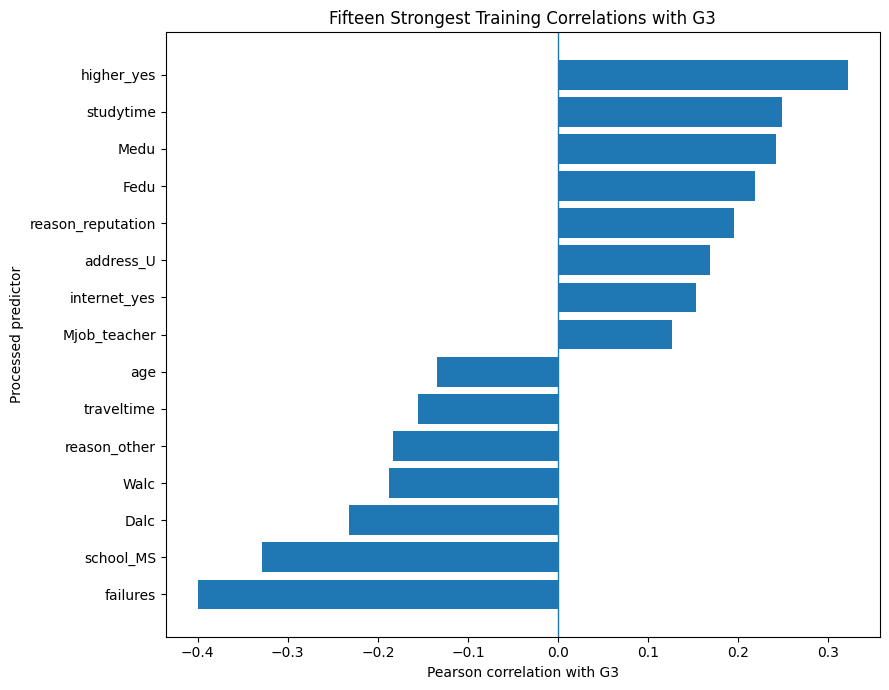

In [ ]:

train_with_target = X_train_combined.copy()

# Add the training target values as a new column so that correlations
# between every processed predictor and G3 can be calculated.
train_with_target["G3"] = y_train

# Calculate the Pearson correlation matrix and select only the correlations
# between each predictor and the target variable G3.
correlation_with_target = (
    train_with_target.corr(numeric_only = True)["G3"]

    # Remove G3's correlation with itself, which is always equal to 1.
    .drop("G3")

    # Rank predictors by the absolute strength of their correlations.
    # np.abs ignores the sign during sorting, so strong positive and
    # strong negative correlations both appear near the top.
    .sort_values(key = np.abs, ascending = False)
)

# Display the ten predictors with the strongest absolute correlations
# with G3. The original positive or negative signs are preserved.
print("Ten strongest absolute correlations with G3:")
display(
    correlation_with_target
    .head(10)
    .to_frame("correlation_with_G3")
)

# Select the 15 predictors with the strongest absolute correlations,
# then sort their actual signed values from most negative to most positive.
# This ordering makes the later horizontal bar chart easier to interpret.
plot_values = correlation_with_target.head(15).sort_values()


plt.figure(figsize=(9, 7))
plt.barh(plot_values.index, plot_values.values)
plt.axvline(0, linewidth=1)
plt.xlabel("Pearson correlation with G3")
plt.ylabel("Processed predictor")
plt.title("Fifteen Strongest Training Correlations with G3")
plt.tight_layout()
plt.show()

## 15 - Identifying highly correlated predictors (multicollinearity check)

Before fitting a multiple linear regression model, it is good practice to examine whether any predictor variables are strongly correlated with one another. When two or more predictors contain very similar information, the model may suffer from multicollinearity.

In this section, you create a reusable function that:

- computes the Pearson correlation matrix for all numerical predictors,
- identifies pairs of predictors with a strong absolute correlation,
- removes duplicate pairs and self-correlations,
- returns only those predictor pairs whose absolute correlation is greater than - or equal to a specified threshold (0.70 in this activity).

>> If no predictor pairs exceed the threshold, we can conclude that the dataset does not contain any strong linear relationships between the predictors based on this criterion.

In [ ]:
# Define a function that identifies pairs of predictors whose absolute
# Pearson correlation is greater than or equal to a specified threshold.
def strong_predictor_correlations(df, threshold = 0.70):

    # Calculate the Pearson correlation matrix using only numerical columns,
    # then convert all correlations to absolute values so that strong
    # positive and strong negative relationships are treated equally.
    correlation_matrix = df.corr(numeric_only = True).abs()

    # Keep only the upper triangle of the correlation matrix.
    # Since the matrix is symmetric (A-B = B-A), this removes duplicate pairs
    # and ignores the diagonal values (self-correlations = 1.0).
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k = 1).astype(bool)
    )

    # Convert the upper triangle from a matrix into a table where each row
    # represents one pair of predictors and their absolute correlation.
    pairs = (
        upper_triangle.stack()
        .rename("absolute_correlation")
        .reset_index()
        .rename(columns={
            "level_0": "predictor_1",
            "level_1": "predictor_2"
        })
    )

    # Keep only predictor pairs whose absolute correlation is greater than
    # or equal to the specified threshold, sort them from strongest to
    # weakest correlation, and reset the row index.
    return (
        pairs[pairs["absolute_correlation"] >= threshold]
        .sort_values("absolute_correlation", ascending = False)
        .reset_index(drop = True)
    )


# Search the processed training data for highly correlated predictor pairs.
strong_pairs = strong_predictor_correlations(
    X_train_combined,
    threshold = 0.70
)

# Display the results. If no highly correlated predictor pairs are found,
# print a message instead of displaying an empty table.
if strong_pairs.empty:
    print("No predictor pairs have |correlation| ≥ 0.70.")
else:
    display(strong_pairs)

,predictor_1,predictor_2,absolute_correlation
0,Fjob_other,Fjob_services,0.7433


## 16 - Fit the scikit-learn linear-regression model

Fit the model using only the processed training data. Then generate predictions for both training and testing sets.

The training predictions help us describe in-sample fit; the testing predictions measure performance on observations that were not used to estimate the coefficients.

In [31]:
model = LinearRegression()

model.fit(X_train_combined, y_train)

y_train_predicted = model.predict(X_train_combined)

y_test_predicted = model.predict(X_test_combined)


In [35]:
# Print the model summary
print("Model fitted successfully")

# Intercept
print(f"Intercept: {model.intercept_:.4f}")

# Coefficients
print("Estimated coefficients:",len(model.coef_))


Model fitted successfully
Intercept: 10.2399
Estimated coefficients: 39


## 17 - Calculate predictive and explanatory metrics

Report:

- **Training `R ^2`:** in-sample explained variation.
- **Training adjusted `R ^2`:** training `R ^2` penalized for the number of predictors.
- **Test `R ^2`:** explained variation in unseen observations.
- **Test RMSE:** typical prediction error expressed in grade points.

The activity handout provides a formula using test-set `n`. Calculate that value separately as a **classroom-adjusted test `R ^2`**, but it should not be confused with the conventional in-sample adjusted `R ^2` used in regression inference.

,metric,value
0,Training R²,0.3874
1,Training adjusted R² (conventional),0.3376
2,Test R²,0.1602
3,Test RMSE,2.8618
4,Adjusted test R² (handout calculation; nonstan...,-0.2038


## 18 - Compare actual and predicted test grades

A prediction table makes the model's errors concrete. The residual is defined as:

>`Residual = Actual G3 - Predicted G3`


Positive residuals indicate underprediction; negative residuals indicate overprediction.

,actual_G3,predicted_G3,residual,absolute_error
603,0,13.0242,-13.0242,13.0242
549,18,9.8546,8.1454,8.1454
163,0,6.8423,-6.8423,6.8423
636,19,13.0726,5.9274,5.9274
514,7,12.6940,-5.6940,5.6940
617,18,12.4388,5.5612,5.5612
606,18,12.5918,5.4082,5.4082
533,16,10.6345,5.3655,5.3655
499,16,10.7898,5.2102,5.2102
212,16,10.8638,5.1362,5.1362


## 19 - Plot residuals against predicted values

For a well-specified linear model, residuals should be scattered around zero without a systematic curve or funnel shape.

This plot is primarily an assumption diagnostic. It can reveal:

- nonlinearity;
- changing residual variance;
- unusual observations;
- clusters not captured by the model.

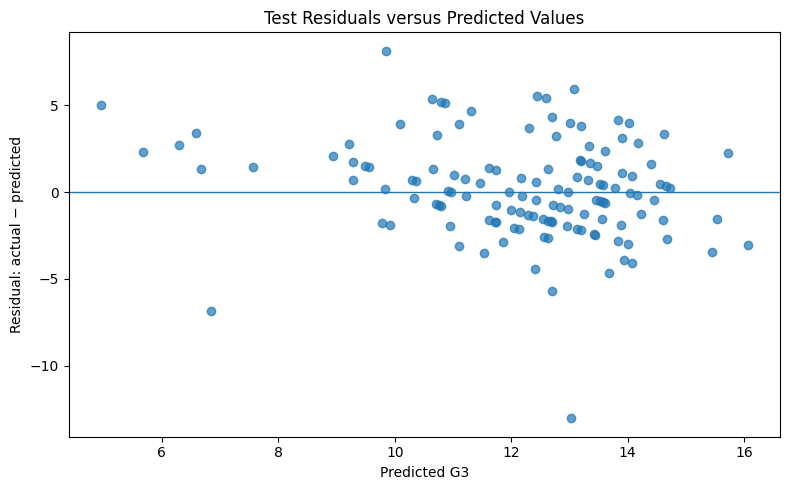

# Recall:
## What is a Q-Q plot?

A Q-Q plot compares the distribution of your sample data with the distribution of a theoretical normal distribution.

In multiple linear regression, we usually create a Q-Q plot of the residuals, not the original data.

Its purpose is to check one of the regression assumptions:

- Are the residuals approximately normally distributed?


One of the assumptions of classical multiple linear regression is:


The residuals should approximately follow a normal distribution with a mean of zero.

The Q-Q plot helps us assess whether this assumption is reasonable.

## 20 - Examine the residual distribution with a Q–Q plot

The Q - Q plot compares residual quantiles with those expected under a normal distribution.

Normal residuals are particularly relevant when interpreting regression p-values and confidence intervals. Small deviations are common; strong curvature or extreme points indicate that the normality assumption may be questionable.

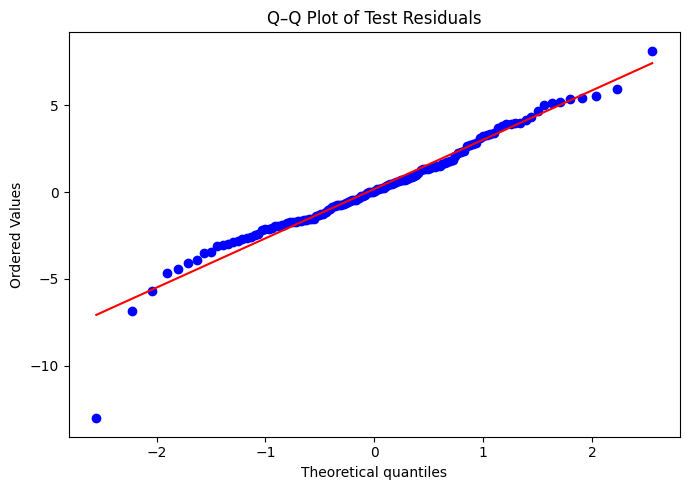

## 21 - Fit the equivalent statsmodels OLS model

Statsmodels provides inferential output such as:

- coefficient standard errors;
- t-tests and p-values;
- confidence intervals;
- the overall F-test;
- adjusted `R²`;
- residual diagnostics.

Add a constant explicitly because `statsmodels.OLS` does not insert an intercept automatically.

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     7.769
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           2.25e-31
Time:                        11:58:20   Log-Likelihood:                -1220.1
No. Observations:                 519   AIC:                             2520.
Df Residuals:                     479   BIC:                             2690.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.2399      2.17

## 22 - Create a concise coefficient-significance table

Each one-hot-encoded category has its own coefficient. Its p-value tests whether that category differs from the omitted reference category, controlling for the other predictors.

For example, an `Mjob_teacher` p-value does **not** test the entire original `Mjob` variable. It tests only the teacher-versus-reference contrast.

Because many coefficients are tested, p-values should be interpreted cautiously rather than treated as automatic feature-selection rules.

,coefficient,standard_error,t_statistic,p_value,ci_lower,ci_upper,significant_at_0.05
failures,-1.4987,0.2342,-6.3983,0.0000,-1.9589,-1.0384,True
const,10.2399,2.1745,4.7092,0.0000,5.9673,14.5126,True
school_MS,-1.3937,0.3022,-4.6121,0.0000,-1.9874,-0.7999,True
higher_yes,1.6869,0.4179,4.0369,0.0001,0.8658,2.5080,True
schoolsup_yes,-1.6034,0.4077,-3.9328,0.0001,-2.4045,-0.8023,True
health,-0.2280,0.0866,-2.6326,0.0087,-0.3982,-0.0578,True
studytime,0.3690,0.1598,2.3093,0.0213,0.0550,0.6830,True
Fjob_services,-1.0993,0.5256,-2.0914,0.0370,-2.1322,-0.0665,True
absences,-0.0509,0.0273,-1.8648,0.0628,-0.1046,0.0027,False
reason_other,-0.7148,0.4187,-1.7075,0.0884,-1.5375,0.1078,False


## 23 - Test complete nominal variables jointly

A nominal variable can produce several dummy columns. To test whether the original variable contributes to the model, jointly test all of its encoded coefficients.

For each nominal variable, the null hypothesis is:

- All dummy coefficients created from this variable are simultaneously equal to zero.

For a binary variable, the joint test contains only one coefficient and is equivalent to its individual t-test squared.

,original_feature,number_of_coefficients_tested,F_statistic,p_value,significant_at_0.05
0,school,1,21.2713,0.0000,True
1,higher,1,16.2966,0.0001,True
2,schoolsup,1,15.4673,0.0001,True
3,sex,1,2.8780,0.0904,False
4,Fjob,4,1.6878,0.1516,False
5,romantic,1,2.0614,0.1517,False
6,reason,3,1.5950,0.1897,False
7,guardian,2,1.5450,0.2144,False
8,internet,1,0.9688,0.3255,False
9,address,1,0.9591,0.3279,False


## 24 - Construct an overall regression ANOVA table

The overall regression ANOVA partitions total variation in training `G3` into:

- **Regression/model variation:** variation explained by the predictor set;
- **Residual/error variation:** variation left unexplained;
- **Total variation:** overall variation around the target mean.

The F-test evaluates whether the regression model provides a better fit than a model containing only the intercept.

The hypotheses are
H0​: β1​=β2​=⋯=βk​=0


If the p-value associated with the F-statistic is less than the chosen significance level (typically 0.05), we reject \(H_0\) and conclude that the regression model is statistically significant.

Rejecting this null means that the predictor set, considered collectively, explains statistically detectable variation beyond an intercept-only model.

,source,sum_of_squares,degrees_of_freedom,mean_square,F_statistic,p_value
0,Regression,2116.6111,39,54.2721,7.7686,0.0000
1,Residual,3346.3291,479,6.9861,NaN,NaN
2,Total,5462.9403,518,NaN,NaN,NaN


## 25 - Calculate variance inflation factors

What is VIF?

VIF measures how much the variance (uncertainty) of a regression coefficient is increased because a predictor is correlated with the other predictors in the model. In simpler terms:

VIF tells us whether a predictor contains information that is already explained by the other predictors.


A large VIF does not prove that a variable is invalid. Dummy variables and related social measures can naturally create some multicollinearity.

There is no universal cutoff, although values above 5 or 10 are often examined more closely. We exclude the intercept from the displayed report.

,predictor,VIF
0,Fjob_other,4.5413
1,Fjob_services,4.2179
2,Medu,2.7501
3,Walc,2.2443
4,Mjob_teacher,2.1753
5,Fedu,2.1081
6,Mjob_services,2.1001
7,Mjob_other,2.0074
8,Dalc,1.9196
9,Fjob_teacher,1.9160


## 26 - Reproduce the workflow with a pipeline

The manual steps above are useful for learning because students can inspect every intermediate DataFrame.

In production work, a `ColumnTransformer` and `Pipeline` are safer because they:

- fit all preprocessing only on training data;
- apply the same transformations automatically to test or future data;
- reduce the risk of column-order mistakes;
- keep preprocessing and modelling in one reusable object.

The pipeline below should reproduce the same test predictions as the manual workflow.

Maximum absolute difference between manual and pipeline predictions:
1.7763568394002505e-15

Pipeline test R²: 0.1601699196431824
Pipeline test RMSE: 2.8617799377344215


## 27 - Summarize the findings programmatically

This final cell generates a concise, reproducible interpretation using the calculated results rather than manually typed values.

The model is useful for demonstrating categorical preprocessing, but reliability should be judged from test performance, residual behaviour, multicollinearity, and the limited information contained in the non-grade predictors.

MODEL SUMMARY
------------------------------------------------------------
Training R²: 0.387
Training adjusted R²: 0.338
Test R²: 0.160
Test RMSE: 2.862 grade points on the 0–20 scale
Handout-style adjusted test R²: -0.204
Overall regression F-test p-value: 0.000000

Interpretation: the model explains only a modest portion of unseen grade variation.
The notebook is most valuable as a preprocessing and regression-learning exercise; it should not be treated as a high-accuracy student-grade prediction system.


#Reflection Questions

1.	Why did we drop G1 and G2 from the very beginning?
2.	Why did we implement data splitting before data encoding?
3.	What are the differences between the applicability of OneHotEncoding and OrdinalEncoding? Could we use other methods such as LabelEncoding or get_dummies?
4.	What is the advantage of using adjusted R2 instead of the original one? Is there anything strange about the value?
5.	Are the results satisfactory as a reliable model? If not, what are the possible reasons for it? How can we improve the performance?
